In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

customers = pd.read_csv('credit_card_customers.csv')

In [2]:
customers.shape

(10127, 23)

In [3]:
customers.tail(20)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
10107,713924283,Attrited Customer,61,M,0,Graduate,Single,R60K - R80K,Blue,54,...,11859.0,1644,10215.0,0.866,8930,79,0.837,0.139,0.992680,0.007320
10108,714471183,Attrited Customer,47,M,4,Graduate,Divorced,R80K - R120K,Blue,39,...,17504.0,476,17028.0,0.892,10468,66,0.737,0.027,0.998160,0.001844
10109,780613758,Existing Customer,47,M,5,High School,Single,Less than R40K,Blue,35,...,4165.0,0,4165.0,0.813,17093,111,0.820,0.000,0.000896,0.999100
10110,718225683,Existing Customer,56,M,1,Graduate,Single,R80K - R120K,Silver,49,...,34516.0,1091,33425.0,0.640,15274,108,0.714,0.032,0.000097,0.999900
10111,710734308,Existing Customer,49,M,1,Graduate,Single,R60K - R80K,Blue,40,...,6481.0,1569,4912.0,0.692,15937,119,0.803,0.242,0.000284,0.999720
10112,708564858,Attrited Customer,33,M,2,College,Married,R120K +,Gold,20,...,34516.0,0,34516.0,1.004,9338,73,0.622,0.000,0.994380,0.005620
10113,713733633,Attrited Customer,27,M,0,High School,Divorced,R60K - R80K,Blue,36,...,13303.0,2517,10786.0,0.929,10219,85,0.809,0.189,0.993380,0.006620
10114,720841533,Existing Customer,29,M,0,Graduate,Married,Less than R40K,Blue,15,...,4700.0,0,4700.0,0.617,14723,96,0.655,0.000,0.000235,0.999770
10115,712210458,Existing Customer,38,M,1,Uneducated,Single,R40K - R60K,Blue,36,...,5639.0,1558,4081.0,0.614,16628,109,0.946,0.276,0.000174,0.999830
10116,714109308,Existing Customer,46,M,5,College,Single,R80K - R120K,Blue,36,...,13187.0,2241,10946.0,0.689,15354,112,0.931,0.170,0.000192,0.999810


In [4]:
customers.dtypes

CLIENTNUM                                                                                                                               int64
Attrition_Flag                                                                                                                         object
Customer_Age                                                                                                                            int64
Gender                                                                                                                                 object
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                        object
Marital_Status                                                                                                                         object
Income

In [5]:
customers.nunique

<bound method DataFrame.nunique of        CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0      768805383  Existing Customer            45      M                3   
1      818770008  Existing Customer            49      F                5   
2      713982108  Existing Customer            51      M                3   
3      769911858  Existing Customer            40      F                4   
4      709106358  Existing Customer            40      M                3   
...          ...                ...           ...    ...              ...   
10122  772366833  Existing Customer            50      M                2   
10123  710638233  Attrited Customer            41      M                2   
10124  716506083  Attrited Customer            44      F                1   
10125  717406983  Attrited Customer            30      M                2   
10126  714337233  Attrited Customer            43      F                2   

      Education_Level Marital_Status Inc

In [34]:
customers = customers.drop(customers.columns[0],axis = 1)

customers = customers.iloc[:, :-7]

customers.head(20)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
0,Existing Customer,45,M,3,High School,Married,R60K - R80K,Blue,39,5,1,3,12691.0,777,11914.0
1,Existing Customer,49,F,5,Graduate,Single,Less than R40K,Blue,44,6,1,2,8256.0,864,7392.0
2,Existing Customer,51,M,3,Graduate,Married,R80K - R120K,Blue,36,4,1,0,3418.0,0,3418.0
3,Existing Customer,40,F,4,High School,Unknown,Less than R40K,Blue,34,3,4,1,3313.0,2517,796.0
4,Existing Customer,40,M,3,Uneducated,Married,R60K - R80K,Blue,21,5,1,0,4716.0,0,4716.0
5,Existing Customer,44,M,2,Graduate,Married,R40K - R60K,Blue,36,3,1,2,4010.0,1247,2763.0
6,Existing Customer,51,M,4,Unknown,Married,R120K +,Gold,46,6,1,3,34516.0,2264,32252.0
7,Existing Customer,32,M,0,High School,Unknown,R60K - R80K,Silver,27,2,2,2,29081.0,1396,27685.0
8,Existing Customer,37,M,3,Uneducated,Single,R60K - R80K,Blue,36,5,2,0,22352.0,2517,19835.0
9,Existing Customer,48,M,2,Graduate,Single,R80K - R120K,Blue,36,6,3,3,11656.0,1677,9979.0


In [12]:
customers.describe(include="all")

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
count,10127,10127.000000,10127,10127.000000,10127,10127,10127,10127,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
unique,2,NaN,2,NaN,7,4,6,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Existing Customer,NaN,F,NaN,Graduate,Married,Less than R40K,Blue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,8500,NaN,5358,NaN,3128,4687,3561,9436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,46.325960,NaN,2.346203,NaN,NaN,NaN,NaN,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637
std,NaN,8.016814,NaN,1.298908,NaN,NaN,NaN,NaN,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324
min,NaN,26.000000,NaN,0.000000,NaN,NaN,NaN,NaN,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000
25%,NaN,41.000000,NaN,1.000000,NaN,NaN,NaN,NaN,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000
50%,NaN,46.000000,NaN,2.000000,NaN,NaN,NaN,NaN,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000
75%,NaN,52.000000,NaN,3.000000,NaN,NaN,NaN,NaN,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000


In [31]:
customers.head(10)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
0,Existing Customer,45,M,3,High School,Married,R60K - R80K,Blue,39,5,1,3,12691.0,777,11914.0
1,Existing Customer,49,F,5,Graduate,Single,Less than R40K,Blue,44,6,1,2,8256.0,864,7392.0
2,Existing Customer,51,M,3,Graduate,Married,R80K - R120K,Blue,36,4,1,0,3418.0,0,3418.0
3,Existing Customer,40,F,4,High School,Unknown,Less than R40K,Blue,34,3,4,1,3313.0,2517,796.0
4,Existing Customer,40,M,3,Uneducated,Married,R60K - R80K,Blue,21,5,1,0,4716.0,0,4716.0
5,Existing Customer,44,M,2,Graduate,Married,R40K - R60K,Blue,36,3,1,2,4010.0,1247,2763.0
6,Existing Customer,51,M,4,Unknown,Married,R120K +,Gold,46,6,1,3,34516.0,2264,32252.0
7,Existing Customer,32,M,0,High School,Unknown,R60K - R80K,Silver,27,2,2,2,29081.0,1396,27685.0
8,Existing Customer,37,M,3,Uneducated,Single,R60K - R80K,Blue,36,5,2,0,22352.0,2517,19835.0
9,Existing Customer,48,M,2,Graduate,Single,R80K - R120K,Blue,36,6,3,3,11656.0,1677,9979.0


In [30]:
high_income_categories = ['$120K +']

for edu in ['Uneducated', 'Doctorate']:
    group = customers[customers['Education_Level'] == edu]
    high  = group[group['Income_Category'].isin(high_income_categories)]
    pct   = (len(high) / len(group)) * 100
    print(f"{edu}: {pct:.2f}% earn R120K or more")

Uneducated: 0.00% earn R120K or more
Doctorate: 0.00% earn R120K or more


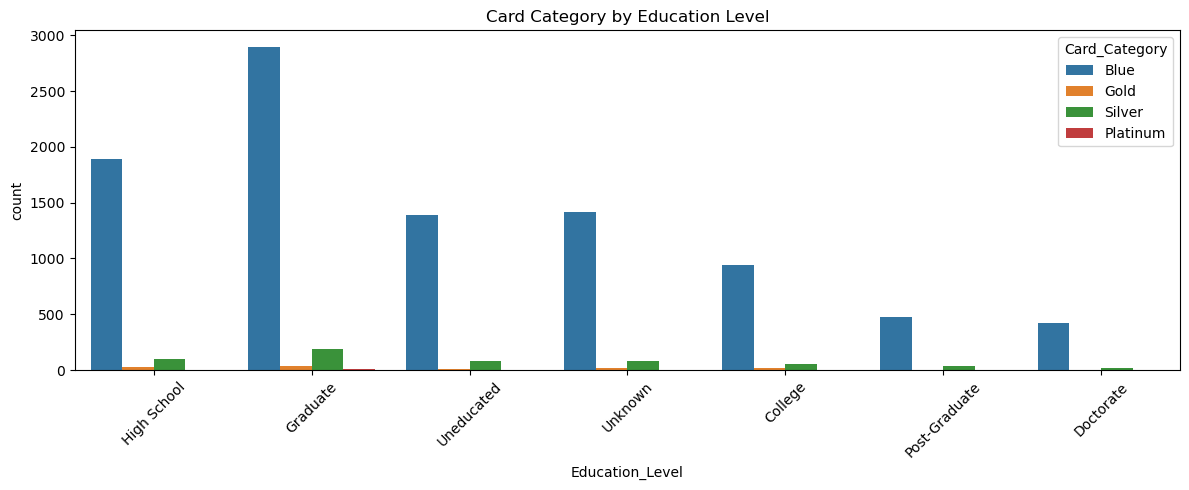

The plot shows that Blue card holders dominate across all education levels.


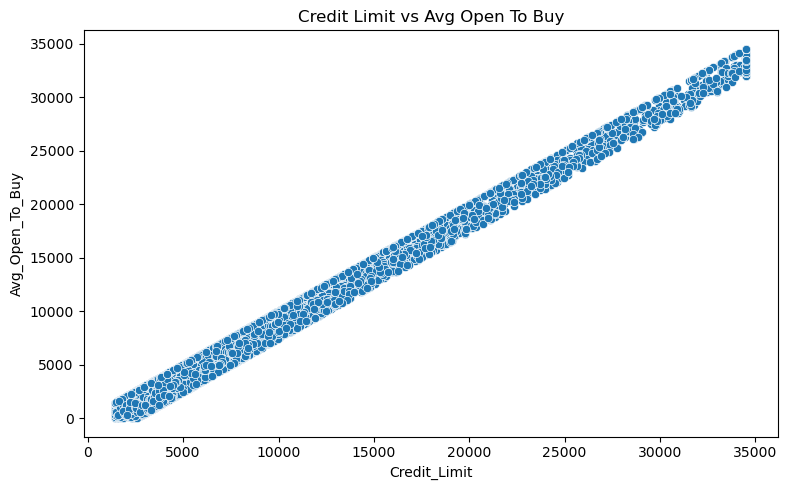

Strong positive correlation — customers with higher credit limits tend to have more open-to-buy credit available.


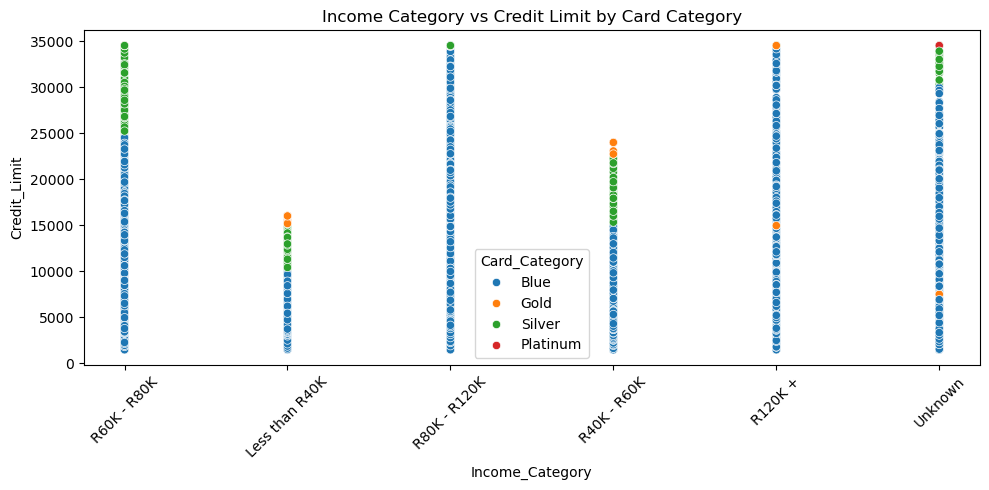

Higher income customers tend to have higher credit limits. Platinum and Gold card holders appear at higher credit limit ranges.


In [35]:
import seaborn as sns

# Category plot: Card Category per Education Level
plt.figure(figsize=(12, 5))
sns.countplot(data=customers, x='Education_Level', hue='Card_Category')
plt.title('Card Category by Education Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("The plot shows that Blue card holders dominate across all education levels.")

# Scatter plot: Credit Limit vs Avg_Open_To_Buy
plt.figure(figsize=(8, 5))
sns.scatterplot(data=customers, x='Credit_Limit', y='Avg_Open_To_Buy')
plt.title('Credit Limit vs Avg Open To Buy')
plt.tight_layout()
plt.show()
print("Strong positive correlation — customers with higher credit limits tend to have more open-to-buy credit available.")

# Combined scatter: Income Category vs Credit Limit by Card Category
plt.figure(figsize=(10, 5))
sns.scatterplot(data=customers, x='Income_Category', y='Credit_Limit', hue='Card_Category')
plt.title('Income Category vs Credit Limit by Card Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Higher income customers tend to have higher credit limits. Platinum and Gold card holders appear at higher credit limit ranges.")

In [36]:
print(customers['Attrition_Flag'].value_counts())

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64


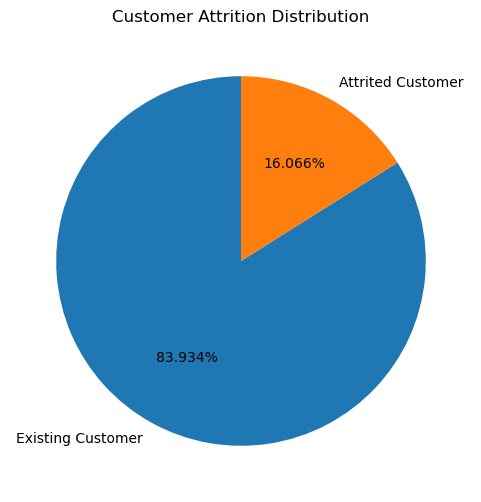

In [37]:
counts = customers['Attrition_Flag'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index,
        autopct=lambda p: f'{p:.3f}%',
        startangle=90)
plt.title('Customer Attrition Distribution')
plt.show()

In [38]:
from sklearn.utils import resample

existing  = customers[customers['Attrition_Flag'] == 'Existing Customer']
attrited  = customers[customers['Attrition_Flag'] == 'Attrited Customer']

# Undersample the majority class to match minority
existing_downsampled = resample(existing,
                                  replace=False,
                                  n_samples=len(attrited),
                                  random_state=42)

customers_resampled = pd.concat([existing_downsampled, attrited])
print(customers_resampled['Attrition_Flag'].value_counts())

Attrition_Flag
Existing Customer    1627
Attrited Customer    1627
Name: count, dtype: int64


In [39]:
customers_resampled = customers_resampled.astype(
    {col: int for col in customers_resampled.select_dtypes('bool').columns}
)

text_cols = customers_resampled.select_dtypes(include=['object']).columns.tolist()

for col in text_cols:
    unique_vals = customers_resampled[col].nunique()
    if unique_vals == 2:
        vals = customers_resampled[col].unique()
        customers_resampled[col] = customers_resampled[col].map({vals[0]: 0, vals[1]: 1})
        print(f"Binary encoded: '{col}' → {vals[0]}=0, {vals[1]}=1")
    elif unique_vals > 2:
        dummies = pd.get_dummies(customers_resampled[col], prefix=col)
        customers_resampled = pd.concat(
            [customers_resampled.drop(columns=[col]), dummies], axis=1
        )
        print(f"One-hot encoded: '{col}'")

print(customers_resampled.head())

Binary encoded: 'Attrition_Flag' → Existing Customer=0, Attrited Customer=1
Binary encoded: 'Gender' → F=0, M=1
One-hot encoded: 'Education_Level'
One-hot encoded: 'Marital_Status'
One-hot encoded: 'Income_Category'
One-hot encoded: 'Card_Category'
      Attrition_Flag  Customer_Age  Gender  Dependent_count  Months_on_book  \
7304               0            53       0                3              46   
8014               0            45       0                2              29   
8271               0            40       1                2              28   
6408               0            53       1                4              48   
7379               0            45       0                4              41   

      Total_Relationship_Count  Months_Inactive_12_mon  Contacts_Count_12_mon  \
7304                         6                       3                      1   
8014                         2                       2                      3   
8271                         1   

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

customers_resampled = customers_resampled.select_dtypes(exclude=['datetime64[ns]'])

X = customers_resampled.drop(columns=['Attrition_Flag'])
y = customers_resampled['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (2603, 31)
X_test shape:  (651, 31)


In [42]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, name, X, y, cv):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=cv,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, label='Training score', color='blue')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, val_mean, label='CV score', color='orange')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
    plt.title(f'Learning Curve — {name}')
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

KNN (acc): 0.5932
KNN (f1):  0.5928
KNN ✓ done



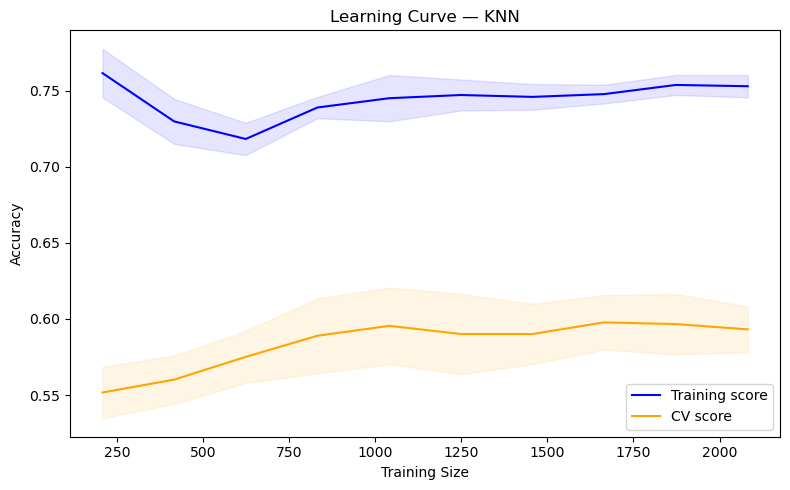

LR (acc): 0.7165
LR (f1):  0.7164
LR ✓ done



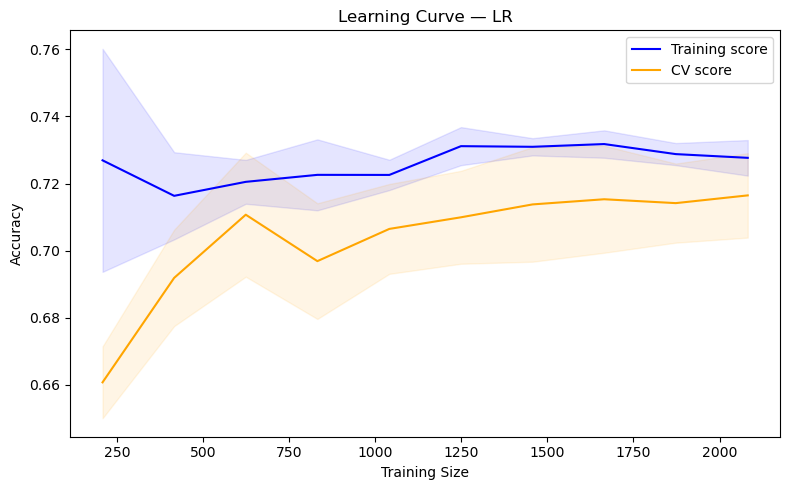

SVM (acc): 0.7234
SVM (f1):  0.7234
SVM ✓ done



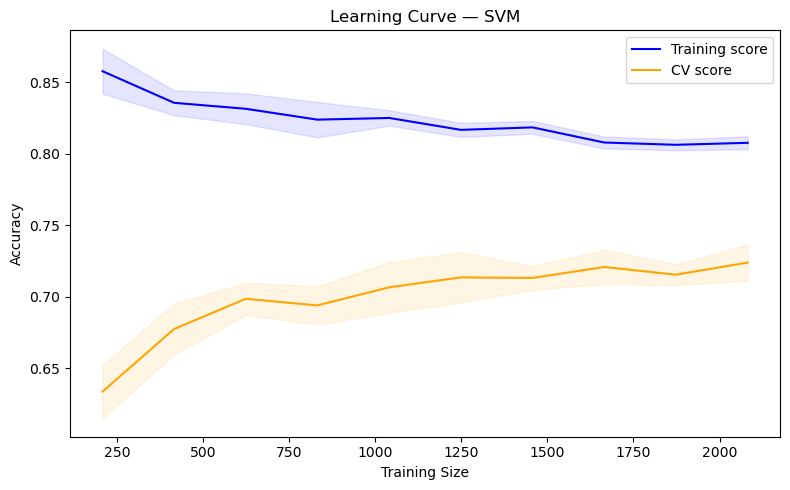

In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import KFold, cross_val_score, learning_curve

models = [
    ('KNN', KNeighborsClassifier()),
    ('LR',  LogisticRegression(solver='lbfgs', max_iter=1000)),
    ('SVM', SVC(gamma='auto'))
]

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
results_acc = []
results_f1  = []
names       = []

for name, model in models:
    acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
    f1_scores  = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='f1_weighted')
    results_acc.append(acc_scores)
    results_f1.append(f1_scores)
    names.append(name)
    print(f'{name} (acc): {acc_scores.mean():.4f}')
    print(f'{name} (f1):  {f1_scores.mean():.4f}')
    print(f'{name} ✓ done\n')
    plot_learning_curve(model, name, X_train_scaled, y_train, kfold)

Best model: SVM (F1 = 0.7234)

Test Accuracy: 0.6820



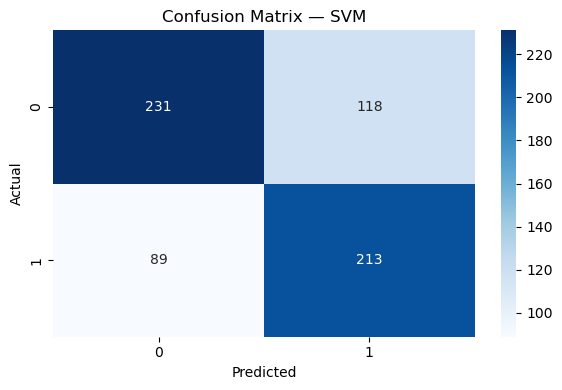

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.66      0.69       349
           1       0.64      0.71      0.67       302

    accuracy                           0.68       651
   macro avg       0.68      0.68      0.68       651
weighted avg       0.69      0.68      0.68       651



In [44]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

f1_means   = [scores.mean() for scores in results_f1]
best_index = f1_means.index(max(f1_means))
best_name  = names[best_index]
best_clf   = dict(models)[best_name]
print(f"Best model: {best_name} (F1 = {f1_means[best_index]:.4f})")

best_clf.fit(X_train_scaled, y_train)
y_pred = best_clf.predict(X_test_scaled)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred))